In [18]:
import torch
import torch.optim as optim
from dataset import get_pennfudan_dataloaders
from models import ObjectCountingModel
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from settings import DATA_DIR
from typing import Literal
import os
from evaluate import evaluate_model

We implemented the following changes with respect to the original training script:
- Create dataloaders outside training function to optimize resources.
- Add the model version to the `ObjectCountingModel` class and training and evaluation functions.
- Save the best and last model checkpoints for each version for a fair comparison between versions to `checkpoints`
- Add early stopping

In [19]:
def train_model(
    train_loader,
    val_loader,
    category_names,
    num_epochs=10,
    learning_rate=0.005,
    version: Literal["v1", "v2"] = "v2",
    patience=5,
    min_delta=1e-4,
):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = ObjectCountingModel(num_classes=2, version=version)
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.SGD(params, lr=learning_rate, momentum=0.3, weight_decay=0.0005)
    lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    map_metric = MeanAveragePrecision(iou_type="bbox").to(device)
    best_map = float("-inf")
    model_patience = patience

    os.makedirs("checkpoints", exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, targets in train_loader:
            images = [image.to(device) for image in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            running_loss += losses.item()

        lr_scheduler.step()

        model.eval()
        map_metric.reset()  # Reset for each epoch
        with torch.no_grad():
            for images, targets in val_loader:
                images = [image.to(device) for image in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

                preds = model(images)
                map_metric.update(preds, targets)

        metrics = map_metric.compute()
        current_map = float(metrics["map"].item())
        current_map50 = float(metrics["map_50"].item())

        epoch_str = f"Epoch {epoch + 1}/{num_epochs}"
        loss_str = f"Loss: {running_loss / len(train_loader):.4f}"
        map_str = f"Val mAP: {current_map:.4f} (mAP@0.5: {current_map50:.4f})"
        print(f"{epoch_str}, {loss_str}\n {map_str}")

        # Early stopping and best checkpoint update.
        if current_map > best_map + min_delta:
            best_map = current_map
            model_patience = patience
            torch.save(
                model.state_dict(),
                f"checkpoints/object_counting_model_{version}_best.pth",
            )
        else:
            model_patience -= 1

        # Always save current epoch state as latest/last checkpoint.
        torch.save(
            model.state_dict(),
            f"checkpoints/object_counting_model_{version}.pth",
        )

        if model_patience == 0:
            print(f"Early stopping triggered. Best mAP: {best_map:.4f}")
            break

    return model, category_names

In [20]:
batch_size = 8
train_loader, val_loader, category_names = get_pennfudan_dataloaders(
    batch_size, root=str(DATA_DIR / "PennFudanPed")
)

In [21]:
shared_params = {
    "num_epochs": 100,
    "train_loader": train_loader,
    "val_loader": val_loader,
    "category_names": category_names,
    "learning_rate": 0.005,
    "patience": 10
}

In [22]:
model_v1 = train_model(**shared_params, version="v1")

Epoch 1/100, Loss: 0.4132
 Val mAP: 0.0041 (mAP@0.5: 0.0185)
Epoch 2/100, Loss: 0.3803
 Val mAP: 0.0060 (mAP@0.5: 0.0267)
Epoch 3/100, Loss: 0.3716
 Val mAP: 0.0075 (mAP@0.5: 0.0335)
Epoch 4/100, Loss: 0.3733
 Val mAP: 0.0076 (mAP@0.5: 0.0340)
Epoch 5/100, Loss: 0.3779
 Val mAP: 0.0077 (mAP@0.5: 0.0346)
Epoch 6/100, Loss: 0.3702
 Val mAP: 0.0078 (mAP@0.5: 0.0342)
Epoch 7/100, Loss: 0.3708
 Val mAP: 0.0079 (mAP@0.5: 0.0343)
Epoch 8/100, Loss: 0.3743
 Val mAP: 0.0079 (mAP@0.5: 0.0344)
Epoch 9/100, Loss: 0.3753
 Val mAP: 0.0079 (mAP@0.5: 0.0348)
Epoch 10/100, Loss: 0.3738
 Val mAP: 0.0079 (mAP@0.5: 0.0348)
Epoch 11/100, Loss: 0.3798
 Val mAP: 0.0079 (mAP@0.5: 0.0348)
Epoch 12/100, Loss: 0.3723
 Val mAP: 0.0079 (mAP@0.5: 0.0348)
Epoch 13/100, Loss: 0.3826
 Val mAP: 0.0079 (mAP@0.5: 0.0349)
Epoch 14/100, Loss: 0.3723
 Val mAP: 0.0079 (mAP@0.5: 0.0349)
Epoch 15/100, Loss: 0.3748
 Val mAP: 0.0079 (mAP@0.5: 0.0349)
Epoch 16/100, Loss: 0.3820
 Val mAP: 0.0079 (mAP@0.5: 0.0349)
Early stopping tr

Object counts: {}


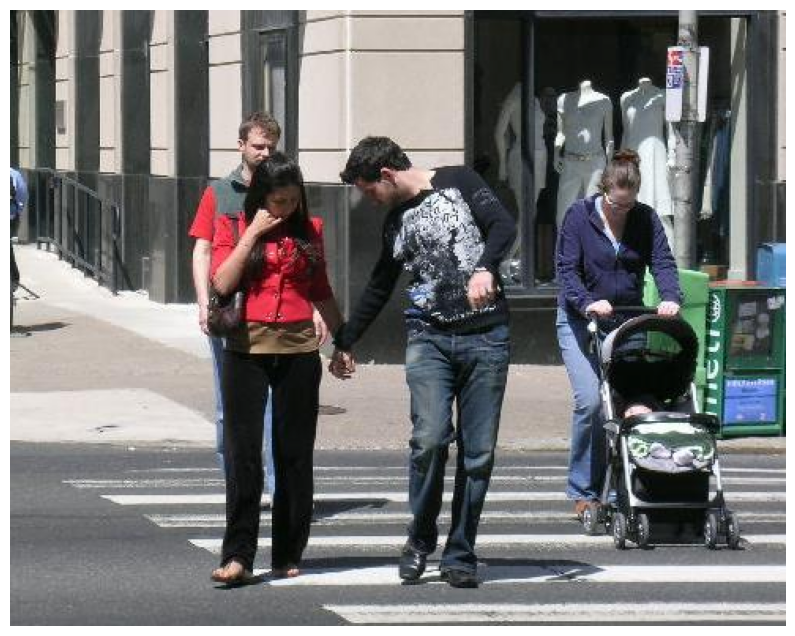

Object counts: {}


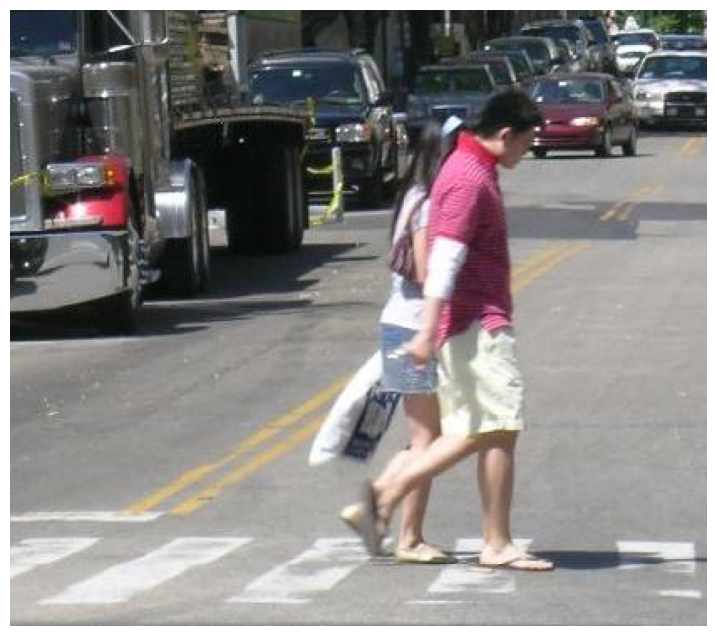

In [23]:
evaluate_model(model_path="checkpoints/object_counting_model_v1_best.pth", version="v1")

In [24]:
model_v2 = train_model(**shared_params, version="v2")

Epoch 1/100, Loss: 0.5683
 Val mAP: 0.5028 (mAP@0.5: 0.7816)
Epoch 2/100, Loss: 0.4423
 Val mAP: 0.5296 (mAP@0.5: 0.8201)
Epoch 3/100, Loss: 0.4109
 Val mAP: 0.5281 (mAP@0.5: 0.8424)
Epoch 4/100, Loss: 0.3944
 Val mAP: 0.5027 (mAP@0.5: 0.8374)
Epoch 5/100, Loss: 0.3867
 Val mAP: 0.5024 (mAP@0.5: 0.8398)
Epoch 6/100, Loss: 0.3837
 Val mAP: 0.5304 (mAP@0.5: 0.8588)
Epoch 7/100, Loss: 0.3934
 Val mAP: 0.5213 (mAP@0.5: 0.8574)
Epoch 8/100, Loss: 0.3903
 Val mAP: 0.5194 (mAP@0.5: 0.8356)
Epoch 9/100, Loss: 0.3787
 Val mAP: 0.5183 (mAP@0.5: 0.8458)
Epoch 10/100, Loss: 0.3798
 Val mAP: 0.5201 (mAP@0.5: 0.8515)
Epoch 11/100, Loss: 0.3961
 Val mAP: 0.5306 (mAP@0.5: 0.8582)
Epoch 12/100, Loss: 0.3908
 Val mAP: 0.5381 (mAP@0.5: 0.8520)
Epoch 13/100, Loss: 0.3836
 Val mAP: 0.5343 (mAP@0.5: 0.8538)
Epoch 14/100, Loss: 0.3942
 Val mAP: 0.5283 (mAP@0.5: 0.8457)
Epoch 15/100, Loss: 0.3993
 Val mAP: 0.5146 (mAP@0.5: 0.8433)
Epoch 16/100, Loss: 0.3889
 Val mAP: 0.5100 (mAP@0.5: 0.8516)
Epoch 17/100, Los

Object counts: {'person': 3}


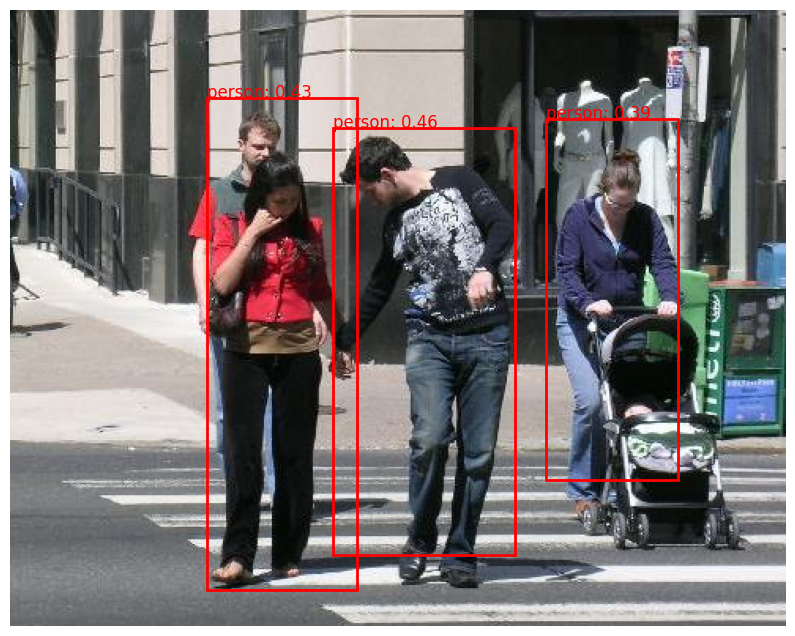

Object counts: {'person': 1}


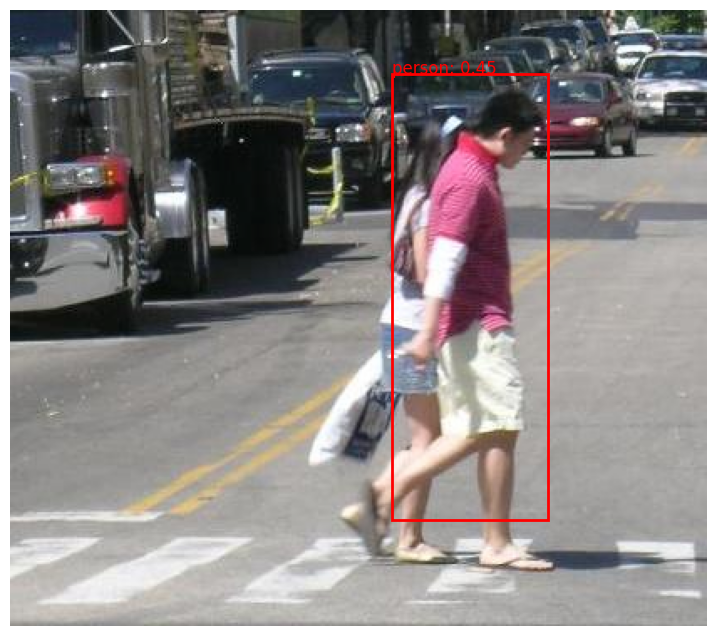

In [25]:
evaluate_model(model_path="checkpoints/object_counting_model_v2_best.pth", version="v2")

- **Tiempo de entrenamiento**: v1 took a lot longer to train, even with early stopping. While v2 was trained for more epochs, each epoch in v1 took longer to train.
- **Tiempo de ejecución**: Both took about the same time to perform the inference.
- **Best mAP**: v2 is better than v1 by a long shot, obtaining a mAP of 0.5381 on the validation set vs 0.0078 obtained by v1. The results are also quite clear in the examples, since v1 wasn't able to recognize even a single person in the images, while v2 recognized all that were clearly visible (it failed on those that didn't appear in full body). Although the confidence for v2 was rather low with all scores bellow 50%, the bounding boxes are excellent.